# Interactive Random-Wave Single-Chain Necklace Scattering

This notebook tests a bead-necklace approximation for one random-wave vortex-line family, `S12 = {phi1 + i phi2 = 0}`.

The trajectory calculation uses finite spherical beads sampled along the traced line (`SCATTERING_AMPLITUDE_METHOD = "balls"`). The model comparison starts from the Gaussian conditional-sampling continuous-line curve and applies a normalized necklace modulation plus a finite spherical bead form factor. The bead diameter is set equal to the arclength separation `b`, and the bead scattering length is `B = lambda*b`, so the average arclength SLD is preserved.

In [1]:
import importlib
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

import rw_line_network as r
import rw_line_scattering as s

r = importlib.reload(r)
s = importlib.reload(s)

print("PyVista", pv.__version__)
print("Notebook imports/reloads complete")

PyVista 0.44.0
Notebook imports/reloads complete


## Parameters

Use `BEAD_BETA = b*k_eff` as the main bead-spacing control. The helper `s.bead_necklace_parameters_from_beta(...)` converts it into the actual trajectory spacing `s.LINE_SAMPLE_SPACING = b`, bead diameter, bead volume SLD, and bead scattering length.

In [2]:
# Random-wave sampling settings
r.GRID_SIZE = 32
r.NUM_BLOCK = 2
r.BLOCK_OVERLAP = 1
r.RANDOM_SEED = 894894
r.NUM_MODES = (128, 128, 128)
r.K_DISTRIBUTION = "gaussian_radial"
r.K0 = (2, 2, 2)
r.r_SIGMA_K = (0.1, 0.1, 0.1)
r.r_K_MIN = (1.0, 1.0, 1.0)
r.r_K_MAX = (1.0, 1.0, 1.0)
r.SHARED_K_VECTORS = False

# phi3 is built by the original structure helper but ignored below.
r.COUPLE_PHI2_PHI3 = False
r.PHI23_COUPLING_C = 0.0

# Vortex tracing settings
r.USE_VORTEX_TRACING = True
r.VORTEX_FACE_PREFILTER = True
r.VORTEX_FACE_ZERO_TOL = 0.02
r.SMOOTH_VORTEX_LINES = True
r.VORTEX_SMOOTHING_SCALE = 1
r.VORTEX_TUBE_RADIUS = 0.25

# Crosslinks are not part of the single-chain test.
r.CROSSLINK_SEARCH_RADIUS = 1.25
r.CROSSLINK_MERGE_RADIUS = 0.5
r.CROSSLINK_BALL_RADIUS = 1.5

# Render preview settings
r.WINDOW_SIZE = (1000, 1000)
r.CAMERA_ZOOM = 0.82
r.CAMERA_AZIMUTH_DEGREES = 30.0
r.CAMERA_POLAR_DEGREES = 60.0
r.SHOW_BOUNDING_BOX = True
r.BOX_SIZE_L = None

# Bead-necklace settings.
k_mean_for_settings = float(np.mean(r._field_parameter_values(r.K0, "K0")))
k_eff_for_settings = 2.0*np.pi*k_mean_for_settings/float(r.GRID_SIZE)
BEAD_BETA = 1.0
BEAD_DIAMETER_OVER_SPACING = 1.0
LINE_SLD_LAMBDA = 1.0
bead_settings = s.bead_necklace_parameters_from_beta(
    BEAD_BETA,
    k_eff_for_settings,
    diameter_over_spacing=BEAD_DIAMETER_OVER_SPACING,
    line_sld=LINE_SLD_LAMBDA,
)

s.LINE_SAMPLE_SPACING = bead_settings["spacing_b"]
s.POINT_WEIGHT_MODE = "arclength"
s.BALL_DIAMETER_OVER_SPACING = BEAD_DIAMETER_OVER_SPACING
s.S12_SCATTERING_WEIGHT = 1.0
s.S13_SCATTERING_WEIGHT = 0.0
s.SCATTERING_AMPLITUDE_METHOD = "balls"
s.SCATTERING_WINDOW = "tukey_box"
s.SCATTERING_WINDOW_TAPER = 0.05
s.SUBTRACT_WINDOWED_MEAN = True
s.WINDOW_MEAN_METHOD = "numeric_1d"
s.WINDOW_NORMALIZATION = "window_squared_volume"
s.SUBTRACT_EXPLICIT_BOX_MEAN = False
s.ANALYTIC_MEAN_BUFFER_BLOCKS = 0
s.ANALYTIC_MEAN_BUFFER_MODE = "none"
s.ANALYTIC_MEAN_BUFFER_NORMALIZE_TOTAL = False
s.DYNAMIC_LINE_SAMPLE_SPACING = False
s.DYNAMIC_LINE_SAMPLE_EXPONENT = 0.5
s.DYNAMIC_LINE_SAMPLE_POWER2_SUBSETS = True
s.INCLUDE_CROSSLINK_POINTS = False
s.CROSSLINK_SCATTERING_WEIGHT = 0.0

# Show the actual beads used for the point-bead trajectory I(Q).
s.SHOW_STRUCTURE_LINES = True
s.SHOW_SCATTERING_SAMPLE_POINTS = True
s.SCATTERING_SAMPLE_POINTS_AS_BALLS = True
s.SCATTERING_SAMPLE_BALL_RADIUS = max(0.15, 0.5*bead_settings["diameter"])
s.SCATTERING_SAMPLE_POINT_COLOR = "#666666"
s.SCATTERING_SAMPLE_POINT_SIZE = 2.0
s.SCATTERING_SAMPLE_POINT_OPACITY = 1.0

s.Q_MIN = 0.08
s.Q_MAX = 6.0
s.NUM_Q = 100
s.Q_SPACING = "log"
s.NUM_Q_DIRECTIONS = 96
s.SCATTERING_SEED = None
s.INTENSITY_NORMALIZATION = "none"
s.NORMALIZE_I0 = False
s.Q_AXIS_SCALE = "mean_k"
s.NUM_SEED_AVERAGE = 8
s.STRUCTURE_SEED_START = r.RANDOM_SEED
s.STRUCTURE_SEED_STRIDE = 1009
s.SCATTERING_FLATTEN_Q_DIRECTIONS = False
s.SCATTERING_Q_CHUNK_SIZE = 10

# Gaussian conditional-sampling comparison.
# The model k-spectrum is dimensionless: MODEL_K0=1 means q_model=Q/k_eff.
# For non-monochromatic tests, match the relative trajectory width/band here.
MODEL_K_DISTRIBUTION = r.K_DISTRIBUTION  # "single_shell", "gaussian_radial", or "uniform_band"
MODEL_K0 = 1.0
MODEL_R_SIGMA_K = float(np.mean(r._field_parameter_values(r.r_SIGMA_K, "r_SIGMA_K")))
MODEL_R_K_MIN = float(np.mean(r._field_parameter_values(r.r_K_MIN, "r_K_MIN")))
MODEL_R_K_MAX = float(np.mean(r._field_parameter_values(r.r_K_MAX, "r_K_MAX")))
MODEL_NUM_K = 256
MODEL_R_MIN = 1e-3
MODEL_R_MAX = 5e2
MODEL_NR = 5000
MODEL_N_SAMP = 2**15
MODEL_TAIL_START_FRACTION = 0.8

NECKLACE_ALPHA = s.NECKLACE_ALPHA_3

print({
    "sampling": {
        "GRID_SIZE": r.GRID_SIZE,
        "NUM_BLOCK": r.NUM_BLOCK,
        "BLOCK_OVERLAP": r.BLOCK_OVERLAP,
        "STITCHED_GRID_SIZE": r.expanded_grid_size(r.GRID_SIZE, r.NUM_BLOCK),
        "K_DISTRIBUTION": r.K_DISTRIBUTION,
        "K0": r.K0,
        "k_eff_for_settings": k_eff_for_settings,
    },
    "bead_necklace": bead_settings,
    "scattering": {
        "LINE_SAMPLE_SPACING_b": s.LINE_SAMPLE_SPACING,
        "POINT_WEIGHT_MODE": s.POINT_WEIGHT_MODE,
        "SCATTERING_AMPLITUDE_METHOD": s.SCATTERING_AMPLITUDE_METHOD,
        "SCATTERING_WINDOW": s.SCATTERING_WINDOW,
        "SUBTRACT_WINDOWED_MEAN": s.SUBTRACT_WINDOWED_MEAN,
        "WINDOW_NORMALIZATION": s.WINDOW_NORMALIZATION,
        "Q_MIN": s.Q_MIN,
        "Q_MAX": s.Q_MAX,
        "NUM_Q": s.NUM_Q,
        "NUM_Q_DIRECTIONS": s.NUM_Q_DIRECTIONS,
        "Q_AXIS_SCALE": s.Q_AXIS_SCALE,
        "NUM_SEED_AVERAGE": s.NUM_SEED_AVERAGE,
        "STRUCTURE_SEEDS": s.structure_seed_values(),
        "SCATTERING_Q_CHUNK_SIZE": s.SCATTERING_Q_CHUNK_SIZE,
    },
    "gaussian_sampling_model": {
        "MODEL_K_DISTRIBUTION": MODEL_K_DISTRIBUTION,
        "MODEL_K0": MODEL_K0,
        "MODEL_R_SIGMA_K": MODEL_R_SIGMA_K,
        "MODEL_R_K_MIN": MODEL_R_K_MIN,
        "MODEL_R_K_MAX": MODEL_R_K_MAX,
        "MODEL_NUM_K": MODEL_NUM_K,
        "MODEL_R_MIN": MODEL_R_MIN,
        "MODEL_R_MAX": MODEL_R_MAX,
        "MODEL_NR": MODEL_NR,
        "MODEL_N_SAMP": MODEL_N_SAMP,
        "MODEL_TAIL_START_FRACTION": MODEL_TAIL_START_FRACTION,
    },
})

{'sampling': {'GRID_SIZE': 32, 'NUM_BLOCK': 2, 'BLOCK_OVERLAP': 1, 'STITCHED_GRID_SIZE': 63, 'K_DISTRIBUTION': 'gaussian_radial', 'K0': (2, 2, 2), 'k_eff_for_settings': 0.39269908169872414}, 'bead_necklace': {'beta': 1.0, 'k_eff': 0.39269908169872414, 'spacing_b': 2.5464790894703255, 'diameter': 2.5464790894703255, 'radius': 1.2732395447351628, 'diameter_over_spacing': 1.0, 'line_sld_lambda': 1.0, 'bead_scattering_length_B': 2.5464790894703255, 'bead_volume': 8.646074337479492, 'bead_volume_sld': 0.29452431127404305}, 'scattering': {'LINE_SAMPLE_SPACING_b': 2.5464790894703255, 'POINT_WEIGHT_MODE': 'arclength', 'SCATTERING_AMPLITUDE_METHOD': 'balls', 'SCATTERING_WINDOW': 'tukey_box', 'SUBTRACT_WINDOWED_MEAN': True, 'WINDOW_NORMALIZATION': 'window_squared_volume', 'Q_MIN': 0.08, 'Q_MAX': 6.0, 'NUM_Q': 100, 'NUM_Q_DIRECTIONS': 96, 'Q_AXIS_SCALE': 'mean_k', 'NUM_SEED_AVERAGE': 8, 'STRUCTURE_SEEDS': [894894, 895903, 896912, 897921, 898930, 899939, 900948, 901957], 'SCATTERING_Q_CHUNK_SIZE':

## Build Trajectories

In [3]:
def status(message):
    print(message, flush=True)


seeds = s.structure_seed_values()
q = s.q_values()
structures = []
original_seed = r.RANDOM_SEED
t_build_all = time.perf_counter()

try:
    for seed_index, seed in enumerate(seeds, start=1):
        label = f"seed {seed_index}/{len(seeds)} ({seed})"
        status(f"[build] {label}: building full line structure...")
        t0 = time.perf_counter()
        r.RANDOM_SEED = int(seed)
        full = s.build_line_structure(
            line_sample_spacing=s.LINE_SAMPLE_SPACING,
            include_crosslinks=False,
            print_timing=True,
            timing_label=label,
        )
        one = s.as_single_s12_structure(full, line_sample_spacing=s.LINE_SAMPLE_SPACING)
        structures.append(one)
        status(
            f"[build] {label}: S12 beads={len(one.points)}, "
            f"segments={len(one.segment_starts)}, done in {time.perf_counter() - t0:.2f}s"
        )
finally:
    r.RANDOM_SEED = original_seed

structure = structures[0]
status(f"[build] all structures complete in {time.perf_counter() - t_build_all:.2f}s")
print("preview seed bead count:", len(structure.points))
print("preview seed segment count:", len(structure.segment_starts))
print("bead spacing b:", s.LINE_SAMPLE_SPACING)
print("bead diameter:", bead_settings["diameter"])
print("point weight value B=lambda*b:", float(structure.weights[0]) if len(structure.weights) else 0.0)

[build] seed 1/8 (894894): building full line structure...
seed 1/8 (894894): fields 0.936s; vortex trace 0.165s; smoothing 0.147s; line point sampling 0.017s; crosslinks 0.000s
seed 1/8 (894894): sampled points 2926 line segments 11666; (S12 1467, S13 1459, crosslinks 0); structure total 1.266s
[build] seed 1/8 (894894): S12 beads=1467, segments=5877, done in 1.27s
[build] seed 2/8 (895903): building full line structure...
seed 2/8 (895903): fields 0.821s; vortex trace 0.176s; smoothing 0.165s; line point sampling 0.024s; crosslinks 0.000s
seed 2/8 (895903): sampled points 2980 line segments 11719; (S12 1490, S13 1490, crosslinks 0); structure total 1.187s
[build] seed 2/8 (895903): S12 beads=1490, segments=5898, done in 1.20s
[build] seed 3/8 (896912): building full line structure...
seed 3/8 (896912): fields 0.829s; vortex trace 0.175s; smoothing 0.162s; line point sampling 0.020s; crosslinks 0.000s
seed 3/8 (896912): sampled points 2998 line segments 11872; (S12 1436, S13 1562, cro

## Preview

c:\Users\ccu\AppData\Local\miniconda\envs\pyvista\Lib\site-packages\pyvista\core\filters\data_set.py:2386: UserWarning: No vector-like data to use for orient. orient will be set to False.
  warnings.warn("No vector-like data to use for orient. orient will be set to False.")


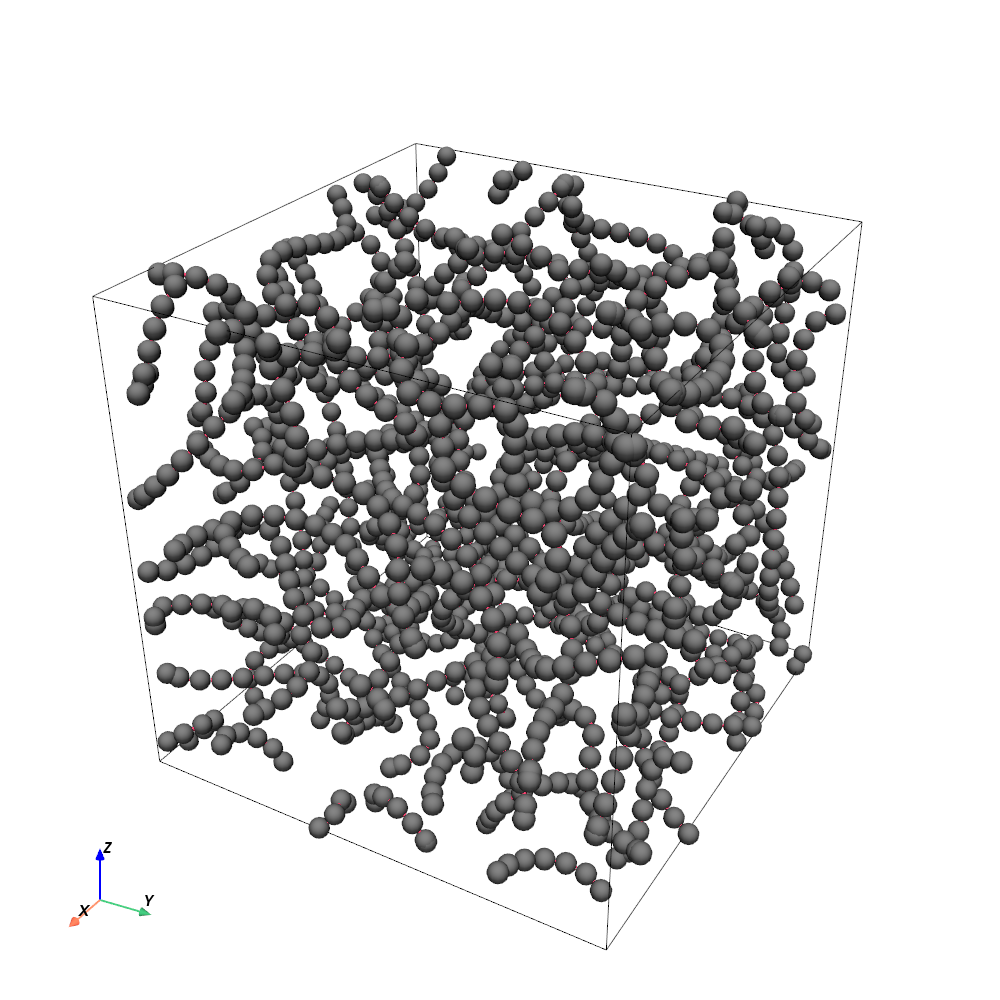

In [4]:
plotter = s.make_structure_plotter(structure)
plotter.show(jupyter_backend="static")

## Scattering And Necklace Conversion

In [5]:
def load_gaussian_sampling_model_module():
    import importlib.util
    import sys
    model_path = Path("smpl") / "rw_line_scattering.py"
    if not model_path.exists():
        model_path = Path.cwd() / "smpl" / "rw_line_scattering.py"
    status(f"[model] loading Gaussian-sampling module from {model_path}...")
    t0 = time.perf_counter()
    spec = importlib.util.spec_from_file_location("rw_line_scattering_smpl", model_path)
    module = importlib.util.module_from_spec(spec)
    assert spec.loader is not None
    sys.modules[spec.name] = module
    spec.loader.exec_module(module)
    status(f"[model] module loaded in {time.perf_counter() - t0:.2f}s")
    return module


def gaussian_sampling_single_chain_reference(q_over_k):
    status(
        f"[model] computing Gaussian-sampling reference: "
        f"k_distribution={MODEL_K_DISTRIBUTION}, K_nodes={MODEL_NUM_K}, "
        f"Nr={MODEL_NR}, N_samp={MODEL_N_SAMP}, Q={len(q_over_k)}"
    )
    t0 = time.perf_counter()
    ris = load_gaussian_sampling_model_module()
    r_model = np.linspace(MODEL_R_MIN, MODEL_R_MAX, MODEL_NR)
    k_radii, k_weights = ris.make_radial_k_quadrature(
        MODEL_NUM_K,
        MODEL_K_DISTRIBUTION,
        k0=MODEL_K0,
        sigma_k=MODEL_R_SIGMA_K*MODEL_K0,
        k_min=MODEL_R_K_MIN*MODEL_K0,
        k_max=MODEL_R_K_MAX*MODEL_K0,
    )
    model_k2_mean = float(np.sum(k_weights * k_radii**2))
    model_line_density_k1 = model_k2_mean / (3.0*np.pi)
    status(
        f"[model] radial k nodes: min={float(np.min(k_radii)):.6g}, "
        f"mean={float(np.sum(k_weights*k_radii)):.6g}, "
        f"sqrt(<k^2>)={np.sqrt(model_k2_mean):.6g}, "
        f"rho_L(unit)={model_line_density_k1:.6g}"
    )
    t_cl0 = time.perf_counter()
    M_J, C_L = ris.compute_CL_general(
        r_model,
        k_radii,
        MODEL_N_SAMP,
        k_weights=k_weights,
        use_qmc=True,
        random_seed=r.RANDOM_SEED,
        progress=True,
    )
    status(f"[model] C_L sampling finished in {time.perf_counter() - t_cl0:.2f}s")
    C_L_coherent = ris.coherent_CL_general(C_L, k_radii, k_weights=k_weights)
    W_tail = ris.tail_window(r_model, MODEL_TAIL_START_FRACTION*MODEL_R_MAX, MODEL_R_MAX)
    t_h0 = time.perf_counter()
    I_model = ris.hankel_transform(r_model, C_L_coherent * W_tail, q_over_k)
    status(f"[model] Hankel transform finished in {time.perf_counter() - t_h0:.2f}s")
    status(f"[model] Gaussian-sampling reference complete in {time.perf_counter() - t0:.2f}s")
    return I_model, {
        "r_model": r_model,
        "M_J": M_J,
        "C_L": C_L,
        "C_L_coherent": C_L_coherent,
        "W_tail": W_tail,
        "k_radii": k_radii,
        "k_weights": k_weights,
        "model_k2_mean": model_k2_mean,
        "model_line_density_k1": model_line_density_k1,
    }


def compute_bead_trajectory_curves():
    curves = []
    diagnostics = []
    t0 = time.perf_counter()
    status(f"[scatter] bead trajectory: starting {len(structures)} seeds")
    for seed_index, (seed, one) in enumerate(zip(seeds, structures), start=1):
        seed_label = f"bead seed {seed_index}/{len(seeds)} ({seed})"
        diag = s.single_chain_window_diagnostics(one)
        diagnostics.append(diag)
        status(
            f"[scatter] {seed_label}: beads={len(one.points)}, "
            f"B={float(one.weights[0]) if len(one.weights) else 0.0:.6g}, "
            f"M_W2={diag['linear_measure_w2']:.6g}"
        )
        curves.append(s.compute_structure_scattering_chunked(one, q, seed_label=seed_label, print_timing=True))
    curve_array = np.asarray(curves, dtype=float)
    mean = np.mean(curve_array, axis=0)
    std = np.std(curve_array, axis=0, ddof=1) if len(curve_array) > 1 else np.zeros_like(mean)
    status(f"[scatter] bead trajectory: complete in {time.perf_counter() - t0:.2f}s")
    return mean, std, diagnostics


t_cell0 = time.perf_counter()
status("[main] starting bead trajectory scattering")
iq_bead_raw, iq_bead_raw_std, bead_diagnostics = compute_bead_trajectory_curves()

status("[main] computing Q-axis metadata and reduced units...")
k_mean = float(np.mean(r._field_parameter_values(r.K0, "K0")))
wave_coordinate_scale = float(r.GRID_SIZE)
k_wave_angular_mean = 2.0 * np.pi * k_mean
k_angular_grid = k_wave_angular_mean / wave_coordinate_scale
box_l = r.BOX_SIZE_L if r.BOX_SIZE_L is not None else float(r.expanded_grid_size(r.GRID_SIZE, r.NUM_BLOCK) - 1)
box_volume_grid = box_l**3
window_volume = s.window_volume()
window_squared_volume = s.window_squared_volume()

bead_d_from_w2 = np.asarray([diag["density_from_w2"] for diag in bead_diagnostics], dtype=float)
d_theory = k_angular_grid**2 / (3.0*np.pi)
d_bead_w2 = float(np.nanmean(bead_d_from_w2))
d = d_bead_w2 if np.isfinite(d_bead_w2) and d_bead_w2 > 0.0 else d_theory
d_source = "bead trajectory window-squared arclength density" if d == d_bead_w2 else "theoretical K^2/(3*pi) fallback"
N = d**2

q_grid_units = q
q_over_k = q / k_angular_grid
q_scaled = q_over_k
q_axis_label = r"$Q/k$"

I_bead_ball = iq_bead_raw / window_squared_volume
I_bead_ball_std = iq_bead_raw_std / window_squared_volume
I_bead_traj_reduced = I_bead_ball / N
I_bead_traj_reduced_std = I_bead_ball_std / N
line_asymptote_reduced = np.pi / np.maximum(q_grid_units * d, np.finfo(float).tiny)

status("[main] computing Gaussian continuous reference...")
I_gaussian_raw, gaussian_model = gaussian_sampling_single_chain_reference(q_over_k)
model_line_density_k1 = float(gaussian_model["model_line_density_k1"])
d_gaussian_theory = k_angular_grid**2 * model_line_density_k1
I_gaussian_cont = k_angular_grid * I_gaussian_raw * (d / d_gaussian_theory)
I_gaussian_cont_reduced = I_gaussian_cont / N

bead_spacing_b = float(s.LINE_SAMPLE_SPACING)
beta = bead_spacing_b * k_angular_grid
bead_runtime = s.bead_necklace_parameters_from_beta(
    beta,
    k_angular_grid,
    diameter_over_spacing=BEAD_DIAMETER_OVER_SPACING,
    line_sld=LINE_SLD_LAMBDA,
)
curvature_length = NECKLACE_ALPHA / k_angular_grid
necklace_curves, necklace_factors = s.convert_continuous_to_necklace(
    q_grid_units,
    I_gaussian_cont,
    k_angular_grid,
    [beta],
    alpha=NECKLACE_ALPHA,
    mode="normalized",
    bead_form_factor=True,
    diameter_over_spacing=BEAD_DIAMETER_OVER_SPACING,
    print_diagnostics=True,
)
I_gaussian_necklace = necklace_curves[beta]
necklace_factor = necklace_factors[beta]
I_gaussian_necklace_reduced = I_gaussian_necklace / N
necklace_modulation_only = s.necklace_modulation(q_over_k, beta, alpha=NECKLACE_ALPHA)
bead_form_factor_amp = s.sphere_bead_form_factor(q_over_k, beta, diameter_over_spacing=BEAD_DIAMETER_OVER_SPACING)
bead_form_factor_intensity = bead_form_factor_amp**2
asymptotic_factor = s.necklace_asymptotic_factor(q_over_k, beta, alpha=NECKLACE_ALPHA) * bead_form_factor_intensity
q_feature = 2.0 * np.pi / beta
curvature_damping = np.exp(-beta / NECKLACE_ALPHA)
q_half_box = 4.0 * np.pi / box_l
q_half_box_scaled = q_half_box / k_angular_grid

status(f"[main] complete in {time.perf_counter() - t_cell0:.2f}s")
print("mean random-wave k in cycles per grid:", k_mean)
print("k_eff angular per grid unit:", k_angular_grid)
print("bead parameters from beta:", bead_runtime)
print("curvature alpha_3:", NECKLACE_ALPHA)
print("curvature coherence length L_c=alpha_3/k_eff:", curvature_length)
print("bead length feature 2*pi/beta:", q_feature)
print("box feature 2*pi/(L/2)/k:", q_half_box_scaled)
print("curvature damping exp(-beta/alpha_3):", curvature_damping)
print("theoretical line density d_theory=K^2/(3*pi):", d_theory)
print("bead W^2 density:", d_bead_w2)
print("line density d used for scaling:", d, d_source)
print("N=d^2:", N)
print("int W^2 dV:", window_squared_volume)

[main] starting bead trajectory scattering
[scatter] bead trajectory: starting 8 seeds
[scatter] bead seed 1/8 (894894): beads=1467, B=2.54648, M_W2=3062.59
[scatter] bead seed 1/8 (894894): scattering 100 Q values in 10 chunks of <= 10
[scatter] bead seed 1/8 (894894): chunk 1/10 Q[0:10] done in 0.56s; elapsed 0.56s, eta 5.05s
[scatter] bead seed 1/8 (894894): chunk 2/10 Q[10:20] done in 0.50s; elapsed 1.06s, eta 4.24s
[scatter] bead seed 1/8 (894894): chunk 3/10 Q[20:30] done in 0.56s; elapsed 1.62s, eta 3.77s
[scatter] bead seed 1/8 (894894): chunk 4/10 Q[30:40] done in 0.56s; elapsed 2.18s, eta 3.27s
[scatter] bead seed 1/8 (894894): chunk 5/10 Q[40:50] done in 0.52s; elapsed 2.71s, eta 2.71s
[scatter] bead seed 1/8 (894894): chunk 6/10 Q[50:60] done in 0.54s; elapsed 3.25s, eta 2.17s
[scatter] bead seed 1/8 (894894): chunk 7/10 Q[60:70] done in 0.52s; elapsed 3.77s, eta 1.62s
[scatter] bead seed 1/8 (894894): chunk 8/10 Q[70:80] done in 0.54s; elapsed 4.32s, eta 1.08s
[scatter] be

## Plot

[plot] rendering necklace comparison plot...
beta: 1.0
bead length feature 2*pi/beta: 6.283185307179586
box feature 2*pi/(L/2)/k: 0.5161290322580645
bead structure factor range: 0.2812033013730182 0.9762836333869966
sphere form factor squared range: 1.909290794085277e-05 0.9979267865845943
combined bead model factor range: 6.798615782507369e-06 0.9742595890610177
[plot] plot cell complete in 0.03s


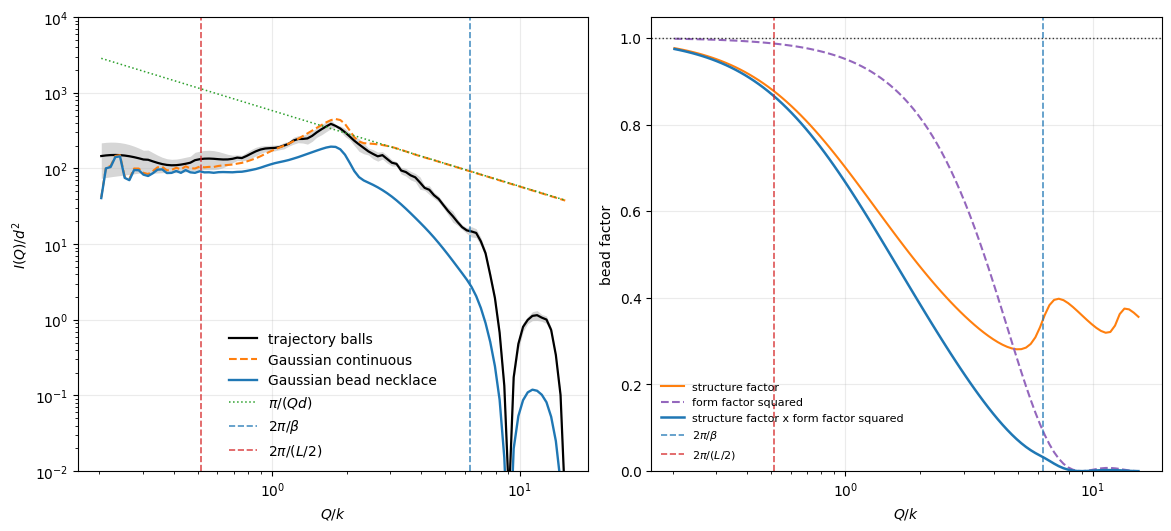

In [9]:
print("[plot] rendering necklace comparison plot...")
t_plot0 = time.perf_counter()
fig, axes = plt.subplots(1, 2, figsize=(11.6, 5.2), constrained_layout=True)
ax = axes[0]

ax.plot(q_scaled, I_bead_traj_reduced, color="black", lw=1.6, label="trajectory balls")
if len(seeds) > 1:
    ax.fill_between(
        q_scaled,
        I_bead_traj_reduced - I_bead_traj_reduced_std,
        I_bead_traj_reduced + I_bead_traj_reduced_std,
        color="black",
        alpha=0.16,
        linewidth=0,
    )
ax.plot(q_over_k, I_gaussian_cont_reduced, color="tab:orange", lw=1.5, ls="--", label="Gaussian continuous")
ax.plot(q_over_k, I_gaussian_necklace_reduced, color="tab:blue", lw=1.7, label="Gaussian bead necklace")
ax.plot(q_scaled, line_asymptote_reduced, color="tab:green", lw=1.1, ls=":", label=r"$\pi/(Qd)$")
ax.axvline(q_feature, color="tab:blue", lw=1.2, ls="--", alpha=0.8, label=r"$2\pi/\beta$")
ax.axvline(q_half_box_scaled, color="tab:red", lw=1.2, ls="--", alpha=0.8, label=r"$2\pi/(L/2)$")
ax.set_ylim(1e-2, 1e4)

ax.set_xlabel(q_axis_label)
ax.set_ylabel(r"$I(Q)/d^2$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(frameon=False)
ax.grid(True, alpha=0.25)

ax = axes[1]
bead_structure_factor = necklace_modulation_only
bead_form_factor = bead_form_factor_intensity
bead_model_factor = necklace_factor

ax.plot(q_over_k, bead_structure_factor, color="tab:orange", lw=1.5, label="structure factor")
ax.plot(q_over_k, bead_form_factor, color="tab:purple", lw=1.5, ls="--", label="form factor squared")
ax.plot(q_over_k, bead_model_factor, color="tab:blue", lw=1.8, label="structure factor x form factor squared")
ax.axhline(1.0, color="0.2", lw=1.0, ls=":")
ax.axvline(q_feature, color="tab:blue", lw=1.2, ls="--", alpha=0.8, label=r"$2\pi/\beta$")
ax.axvline(q_half_box_scaled, color="tab:red", lw=1.2, ls="--", alpha=0.8, label=r"$2\pi/(L/2)$")
ax.set_xlabel(q_axis_label)
ax.set_ylabel("bead factor")
ax.set_xscale("log")
ax.set_ylim(bottom=0.0)
ax.legend(frameon=False, fontsize=8)
ax.grid(True, alpha=0.25)

print("beta:", beta)
print("bead length feature 2*pi/beta:", q_feature)
print("box feature 2*pi/(L/2)/k:", q_half_box_scaled)
print("bead structure factor range:", float(np.nanmin(bead_structure_factor)), float(np.nanmax(bead_structure_factor)))
print("sphere form factor squared range:", float(np.nanmin(bead_form_factor)), float(np.nanmax(bead_form_factor)))
print("combined bead model factor range:", float(np.nanmin(bead_model_factor)), float(np.nanmax(bead_model_factor)))
print(f"[plot] plot cell complete in {time.perf_counter() - t_plot0:.2f}s")


## Save Data

In [7]:
print("[save] saving necklace scattering outputs...")
t_save0 = time.perf_counter()
np.savez_compressed(
    "rw_single_chain_necklace_compare.npz",
    q=q,
    q_over_k=q_over_k,
    beta=beta,
    bead_spacing_b=bead_spacing_b,
    bead_diameter=bead_runtime["diameter"],
    bead_volume=bead_runtime["bead_volume"],
    bead_scattering_length_B=bead_runtime["bead_scattering_length_B"],
    bead_volume_sld=bead_runtime["bead_volume_sld"],
    k_angular_grid=k_angular_grid,
    curvature_alpha=NECKLACE_ALPHA,
    curvature_length=curvature_length,
    q_feature=q_feature,
    q_half_box_scaled=q_half_box_scaled,
    curvature_damping=curvature_damping,
    iq_bead_raw=iq_bead_raw,
    iq_bead_raw_std=iq_bead_raw_std,
    I_bead_ball=I_bead_ball,
    I_bead_ball_std=I_bead_ball_std,
    I_bead_traj_reduced=I_bead_traj_reduced,
    I_bead_traj_reduced_std=I_bead_traj_reduced_std,
    I_gaussian_raw=I_gaussian_raw,
    I_gaussian_cont=I_gaussian_cont,
    I_gaussian_cont_reduced=I_gaussian_cont_reduced,
    I_gaussian_necklace=I_gaussian_necklace,
    I_gaussian_necklace_reduced=I_gaussian_necklace_reduced,
    necklace_factor=necklace_factor,
    necklace_modulation_only=necklace_modulation_only,
    bead_form_factor_intensity=bead_form_factor_intensity,
    asymptotic_factor=asymptotic_factor,
    line_asymptote_reduced=line_asymptote_reduced,
    d=d,
    d_source=d_source,
    d_theory=d_theory,
    d_bead_w2=d_bead_w2,
    N=N,
    window_squared_volume=window_squared_volume,
    seeds=np.asarray(seeds),
    point_counts=np.asarray([len(one.points) for one in structures]),
)

header = "Q,Q_over_k,I_bead_traj_reduced,I_gaussian_cont_reduced,I_gaussian_necklace_reduced,necklace_factor,necklace_M_only,bead_form_factor_intensity,asymptotic_factor,line_asymptote_reduced"
np.savetxt(
    "rw_single_chain_necklace_iq.csv",
    np.column_stack([
        q,
        q_over_k,
        I_bead_traj_reduced,
        I_gaussian_cont_reduced,
        I_gaussian_necklace_reduced,
        necklace_factor,
        necklace_modulation_only,
        bead_form_factor_intensity,
        asymptotic_factor,
        line_asymptote_reduced,
    ]),
    delimiter=",",
    header=header,
    comments="",
)
print("rw_single_chain_necklace_compare.npz")
print("rw_single_chain_necklace_iq.csv")
print(f"[save] save cell complete in {time.perf_counter() - t_save0:.2f}s")

[save] saving necklace scattering outputs...
rw_single_chain_necklace_compare.npz
rw_single_chain_necklace_iq.csv
[save] save cell complete in 0.01s
